### __Git repository:__
https://github.com/KeremOzemre/Computational-Social-Science.git

#### __Main areas of contributions:__

##### __Part 1:__ s244794 20%, s245290 40%, s244322 40%
##### __Part 2:__ s244794 50%, s245290 25%, s244322 25%


In [1]:
import pickle
import networkx as nx
import pandas as pd
import ast
from collections import Counter
import numpy as np

## __Part 1: Mixing Patterns and Assortativity__

### __Exercise 1: Mixing Patterns and Assortativity__

### __Part 1: Assortativity Coefficient__

##### 1. Calculate the Assortativity Coefficient for the network based on the country of each node. Implement the calculation using the formula provided during the lecture, also available in this paper (equation 2, here for directed networks). Do not use the NetworkX implementation.

In [2]:
with open("network/G_social_compute.pkl", "rb") as f:
    G_social_compute = pickle.load(f)

for node in list(G_social_compute.nodes())[:5]:
    print(G_social_compute.nodes[node])

{'display_name': 'Ingram Olkin', 'country': 'US', 'first_publication_year': 1988, 'total_citations': 13344}
{'display_name': 'Larry V. Hedges', 'country': 'US', 'first_publication_year': 1981, 'total_citations': 20290}
{'display_name': 'Stanley Wasserman', 'country': 'US', 'first_publication_year': 1988, 'total_citations': 11053}
{'display_name': 'Katherine L. Milkman', 'country': nan, 'first_publication_year': 2007, 'total_citations': 7440}
{'display_name': 'Jonah Berger', 'country': 'US', 'first_publication_year': 2008, 'total_citations': 4146}


In [3]:
from collections import defaultdict

mixing = defaultdict(int)

for u, v in G_social_compute.edges():

    cu = G_social_compute.nodes[u]['country']
    cv = G_social_compute.nodes[v]['country']

    mixing[(cu, cv)] += 1
    mixing[(cv, cu)] += 1
    
m = G_social_compute.number_of_edges()

for key in mixing:
    mixing[key] /= (2*m)
    
    
a = defaultdict(float)

for (i,j), val in mixing.items():
    a[i] += val

In [4]:
sum_eii = sum(val for (i,j), val in mixing.items() if i == j)

sum_aibi = sum(a[i]*a[i] for i in a)

r = (sum_eii - sum_aibi) / (1 - sum_aibi)

print("Country assortativity:", r)

Country assortativity: 0.2619603572790416


### __Part 2: Configuration model__ In the following, we are going to assess the significance of the assortativity by comparing the network's assortativity coefficient against that of random networks generated through the configuration model.

##### Implement the configuration model using the double edge swap algorithm to generate random networks. Ensure each node retains its original degree but with altered connections. Create a function that does that by following these steps:

##### __2.__ 
- a. Create an exact copy of your original network.
- b. Select two edges, and , ensuring u != y and v != x.
- c. Flip the direction of 
 to 
 50% of the time. This ensure that your final results is not biased, in case your edges were sorted (they usually are).
- d. Ensure that new edges 
 and 
 do not already exist in the network.
- e. Remove edges and 
 and add edges and 
- f. Repeat steps b to e until you have performed  swaps, where E is the total number of edges.


In [5]:
import random

def double_edge_swap_algo(G, n_swaps=None, max_tries_per_swap=20, seed=None):
   
    if seed is not None:
        random.seed(seed)

    G_rand = G.copy()
    E = G_rand.number_of_edges()

    if n_swaps is None:
        n_swaps = 10 * E

    max_tries = max_tries_per_swap * n_swaps

    def canon(a, b):
        return (a, b) if a < b else (b, a)

    edges = [canon(u, v) for u, v in G_rand.edges()]
    edge_set = set(edges)
    edge_to_idx = {e: i for i, e in enumerate(edges)}

    successful_swaps = 0
    tries = 0

    while successful_swaps < n_swaps and tries < max_tries:
        tries += 1

        i1, i2 = random.sample(range(len(edges)), 2)

        u, v = edges[i1]
        x, y = edges[i2]

        if len({u, v, x, y}) < 4:
            continue

        # flip first edge 50% of the time
        if random.random() < 0.5:
            u, v = v, u

        # proposed new edges
        e1_new = canon(u, y)
        e2_new = canon(x, v)

        # avoid self-loops
        if u == y or x == v:
            continue

        # avoid duplicates / existing edges
        if e1_new in edge_set or e2_new in edge_set:
            continue
        
        e1_old = canon(u, v)
        e2_old = canon(x, y)
        
        if e1_old == e2_old:
            continue

        G_rand.remove_edge(*e1_old)
        G_rand.remove_edge(*e2_old)
        G_rand.add_edge(*e1_new)
        G_rand.add_edge(*e2_new)

        edge_set.remove(e1_old)
        edge_set.remove(e2_old)
        edge_set.add(e1_new)
        edge_set.add(e2_new)

        edges[i1] = e1_new
        edges[i2] = e2_new

        del edge_to_idx[e1_old]
        del edge_to_idx[e2_old]
        edge_to_idx[e1_new] = i1
        edge_to_idx[e2_new] = i2

        successful_swaps += 1

        if successful_swaps % 50000 == 0:
            print(f"{successful_swaps} successful swaps completed...")

    print(f"Finished: {successful_swaps} successful swaps out of requested {n_swaps}")
    print(f"Total attempts: {tries}")

    if successful_swaps < n_swaps:
        print("Warning: stopped before reaching requested swaps. You can increase max_tries_per_swap.")

    return G_rand

In [6]:
G_rand = double_edge_swap_algo(
    G_social_compute,
    n_swaps=10 * G_social_compute.number_of_edges(),
    max_tries_per_swap=20,
    seed=42
)

50000 successful swaps completed...
100000 successful swaps completed...
150000 successful swaps completed...
200000 successful swaps completed...
250000 successful swaps completed...
300000 successful swaps completed...
350000 successful swaps completed...
400000 successful swaps completed...
450000 successful swaps completed...
500000 successful swaps completed...
550000 successful swaps completed...
600000 successful swaps completed...
650000 successful swaps completed...
700000 successful swaps completed...
Finished: 705150 successful swaps out of requested 705150
Total attempts: 708998


##### __3. Double check that your algorithm works well, by showing that the degree of nodes in the original network and the new 'randomized' version of the network are the same.__

In [7]:
original_degrees = dict(G_social_compute.degree())
randomized_degrees = dict(G_rand.degree())

print("Degrees preserved:", original_degrees == randomized_degrees)
print("Original nodes:", G_social_compute.number_of_nodes(), " Randomized nodes:", G_rand.number_of_nodes())
print("Original edges:", G_social_compute.number_of_edges(), " Randomized edges:", G_rand.number_of_edges())

Degrees preserved: True
Original nodes: 18912  Randomized nodes: 18912
Original edges: 70515  Randomized edges: 70515


### __Part 3: Analyzing Assortativity in Random Networks__

##### __4. Generate and analyze at least 100 random networks using the configuration model. For each, calculate the assortativity with respect to the country and plot the distribution of these values.__

In [8]:
from collections import defaultdict

def calculate_country_assortativity(G, country_attr='country'):
    mixing = defaultdict(int)

    for u, v in G.edges():
        cu = G.nodes[u][country_attr]
        cv = G.nodes[v][country_attr]

        mixing[(cu, cv)] += 1
        mixing[(cv, cu)] += 1

    m = G.number_of_edges()

    for key in mixing:
        mixing[key] /= (2 * m)

    a = defaultdict(float)
    for (i, j), val in mixing.items():
        a[i] += val

    sum_eii = sum(val for (i, j), val in mixing.items() if i == j)
    sum_aibi = sum(a[i] * a[i] for i in a)

    r = (sum_eii - sum_aibi) / (1 - sum_aibi)
    return r

##### Original network country assortativity

In [9]:
observed_country_r = calculate_country_assortativity(G_social_compute, country_attr='country')
print("Observed country assortativity:", observed_country_r)

Observed country assortativity: 0.2619603572790416


##### Random Network Generation

In [11]:
import time


random_country_assortativities = []

n_random_networks = 100
n_swaps = 10 * G_social_compute.number_of_edges()

start_time = time.time()

for i in range(n_random_networks):
    print(f"Random network {i+1}/{n_random_networks}")

    SG_rand = double_edge_swap_algo(
        G_social_compute,
        n_swaps=n_swaps,
        seed=42 + i
    )

    r_rand = calculate_country_assortativity(SG_rand, country_attr='country')
    random_country_assortativities.append(r_rand)

end_time = time.time()

print("Done.")
print(f"Total runtime: {end_time - start_time:.2f} seconds")

Random network 1/100
50000 successful swaps completed...
100000 successful swaps completed...
150000 successful swaps completed...
200000 successful swaps completed...
250000 successful swaps completed...
300000 successful swaps completed...
350000 successful swaps completed...
400000 successful swaps completed...
450000 successful swaps completed...
500000 successful swaps completed...
550000 successful swaps completed...
600000 successful swaps completed...
650000 successful swaps completed...
700000 successful swaps completed...
Finished: 705150 successful swaps out of requested 705150
Total attempts: 708998
Random network 2/100
50000 successful swaps completed...
100000 successful swaps completed...
150000 successful swaps completed...
200000 successful swaps completed...
250000 successful swaps completed...
300000 successful swaps completed...
350000 successful swaps completed...
400000 successful swaps completed...
450000 successful swaps completed...
500000 successful swaps comp

##### Plotting Social Computation Network's and Random Networks' Country Assortativity

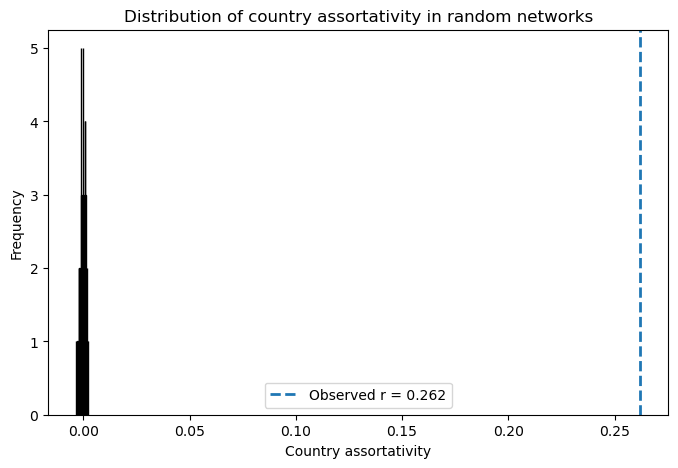

In [12]:
#plotter så  de 100 rnadom netwroks assotritvity ift. vores på 0.26

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 5))
plt.hist(random_country_assortativities, bins=100, edgecolor='black')
plt.axvline(observed_country_r, linestyle='--', linewidth=2, label=f'Observed r = {observed_country_r:.3f}')
plt.xlabel("Country assortativity")
plt.ylabel("Frequency")
plt.title("Distribution of country assortativity in random networks")
plt.legend()
plt.show()

##### Compare the results with the assortativity of your original network to determine if connections within the same country are significantly higher than chance.

In [13]:
random_mean = np.mean(random_country_assortativities)
random_std = np.std(random_country_assortativities)

print("Mean random assortativity:", random_mean)
print("Std random assortativity:", random_std)

Mean random assortativity: -0.00013290279657482515
Std random assortativity: 0.001088371439290293


In [14]:
p_value = np.mean(np.array(random_country_assortativities) >= observed_country_r)
print("Empirical p-value:", p_value)

Empirical p-value: 0.0


### __Part 4: Assortativity by Degree__

In [15]:
def calculate_degree_assortativity(G):

    ku_list = []
    kv_list = []

    for u, v in G.edges():

        ku = G.degree(u)
        kv = G.degree(v)

        ku_list.append(ku)
        kv_list.append(kv)

    ku = np.array(ku_list)
    kv = np.array(kv_list)

    mean_ku = np.mean(ku)
    mean_kv = np.mean(kv)

    mean_ku_kv = np.mean(ku * kv)

    mean_ku2 = np.mean(ku**2)
    mean_kv2 = np.mean(kv**2)

    numerator = mean_ku_kv - (mean_ku * mean_kv)

    denominator = np.sqrt(mean_ku2 - mean_ku**2) * np.sqrt(mean_kv2 - mean_kv**2)

    r = numerator / denominator

    return r

##### __5. Calculate degree assortativity for your network using the formula discussed in the lecture.__

In [16]:
observed_degree_r = calculate_degree_assortativity(G_social_compute)

print("Observed degree assortativity:", observed_degree_r)

Observed degree assortativity: 0.0036452555475442643


##### __6. Compare your network's degree assortativity against that of 100 random networks generated via the configuration model. Analyze whether your network shows a tendency for high-degree scientists to connect with other high-degree scientists and vice versa.__

In [17]:
random_degree_assortativities = []

n_random_networks = 100
n_swaps = 10 * G_social_compute.number_of_edges()

for i in range(n_random_networks):

    print(f"Random network {i+1}/{n_random_networks}")

    SG_rand = double_edge_swap_algo(
        G_social_compute,
        n_swaps=n_swaps,
        seed=100 + i
    )

    r_rand = calculate_degree_assortativity(SG_rand)

    random_degree_assortativities.append(r_rand)

Random network 1/100
50000 successful swaps completed...
100000 successful swaps completed...
150000 successful swaps completed...
200000 successful swaps completed...
250000 successful swaps completed...
300000 successful swaps completed...
350000 successful swaps completed...
400000 successful swaps completed...
450000 successful swaps completed...
500000 successful swaps completed...
550000 successful swaps completed...
600000 successful swaps completed...
650000 successful swaps completed...
700000 successful swaps completed...
Finished: 705150 successful swaps out of requested 705150
Total attempts: 708869
Random network 2/100
50000 successful swaps completed...
100000 successful swaps completed...
150000 successful swaps completed...
200000 successful swaps completed...
250000 successful swaps completed...
300000 successful swaps completed...
350000 successful swaps completed...
400000 successful swaps completed...
450000 successful swaps completed...
500000 successful swaps comp

##### Plotting by Degree Assortavity - Random and Social Computation Networks

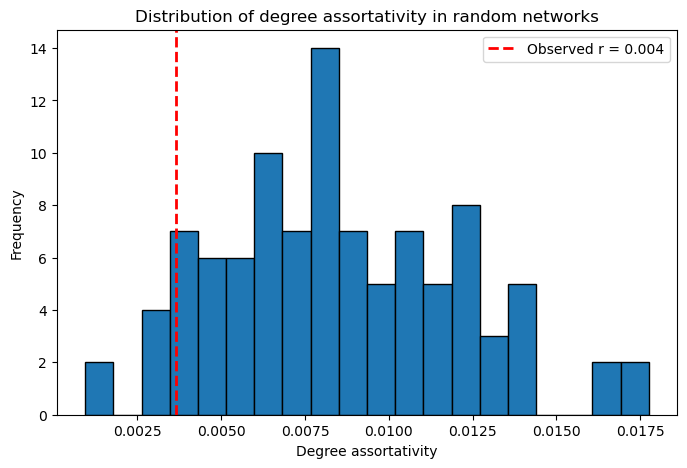

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(random_degree_assortativities, bins=20, edgecolor='black')

plt.axvline(
    observed_degree_r,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Observed r = {observed_degree_r:.3f}'
)

plt.xlabel("Degree assortativity")
plt.ylabel("Frequency")
plt.title("Distribution of degree assortativity in random networks")

plt.legend()
plt.show()

In [19]:
print("Observed degree assortativity:", observed_degree_r)
print("Mean random assortativity:", np.mean(random_degree_assortativities))
print("Std random assortativity:", np.std(random_degree_assortativities))

Observed degree assortativity: 0.0036452555475442643
Mean random assortativity: 0.008475404868227421
Std random assortativity: 0.0035530813536816365


### __Part 5: Reflection questions__

##### __7. Assortativity by degree. Were the results of the degree assortativity in line with your expectations? Why or why not?__

##### __8. Edge flipping. In the process of implementing the configuration model, you were instructed to flip the edges (e.g., changing from (u,v) to (v,u)) 50% of the time. Why do you think this step is included?__

##### __9. Distribution of assortativity in random networks. Describe the distribution of degree assortativity values you observed for the random networks. Was the distribution pattern expected? Discuss how the nature of random network generation (specifically, the configuration model and edge flipping) might influence this distribution and whether it aligns with theoretical expectations.__

## __Part 2: TF - IDF__

### __Exercise 1: TF-IDF and the Computational Social Science communities. The goal for this exercise is to find the words characterizing each of the communities of Computational Social Scientists. What you need for this exercise:__

- #####  The assignment of each author to their network community, and the degree of each author (Week 6, Exercise 4). This can be stored in a dataframe or in two dictionaries, as you prefer.


In [62]:
with open("network/G_social_compute.pkl", "rb") as f:
    G_social_compute = pickle.load(f)

In [63]:
louvain_social_compute = nx.community.louvain_communities(G_social_compute,seed = 100)

In [64]:
papers_dataset = pd.read_csv("/Users/keremozemre/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/social compute/Computational-Social-Science/more_than_one_author_papers_dataset.csv")
papers_dataset["author_ids"] = papers_dataset["author_ids"].apply(ast.literal_eval)

##### The degree of each author, and their community id are just assigned as new features to the social computation network

In [65]:
for community_id, community_nodes in enumerate(louvain_social_compute):
    for node in community_nodes:
        G_social_compute.nodes[node]['community'] = community_id

for node, deg in G_social_compute.degree():
    G_social_compute.nodes[node]['degree'] = deg

##### Check if assignment is correct

In [66]:
G_social_compute.nodes['https://openalex.org/A5013693751']

{'display_name': 'Ingram Olkin',
 'country': 'US',
 'first_publication_year': 1988,
 'total_citations': 13344,
 'community': 26,
 'degree': 3}

- #####  The tokenized abstract dataframe (Week 7, Exercise 2)

In [67]:
tokenized_abstract = pd.read_csv('/Users/keremozemre/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/social compute/Computational-Social-Science/tokenized_abstract2.csv')

##### __1. First, check out the wikipedia page for TF-IDF. Explain in your own words the point of TF-IDF.__

- ##### __What does TF stand for?__

TF (Term Frequency) measures how important a term t is within a specific document D. It is calculated as the number of times the term appears in the document, normalized by the total number of terms in that document.
TF provides a local measure of importance, meaning it reflects how relevant a term is within a single document. However, it does not account for how common or rare the term is across the entire corpus.

---

- ##### __What does IDF stand for?__

IDF (Inverse Document Frequency) measures how unique or rare a term t is across a collection of documents (the corpus). Instead of focusing on how often a term appears within a single document, IDF considers how many documents contain that term.
It is computed by comparing the total number of documents to the number of documents in which the term appears, typically using a logarithmic scale.
IDF assigns higher values to terms that appear in fewer documents, making them more informative. Conversely, terms that appear in many documents (common words like “the” or “is”) receive lower scores.

##### __2. Now, we want to find out which words are important for each community, so we're going to create several large documents, one for each community. Each document includes all the tokens of abstracts written by members of a given community.__

In [68]:
import ast
import pandas as pd

author_to_community = {
    node: G_social_compute.nodes[node]['community']
    for node in G_social_compute.nodes
}

def paper_community(author_ids):
    for aid in author_ids:
        if aid in author_to_community:
            return author_to_community[aid]
    return None

papers_dataset['community_id'] = papers_dataset['author_ids'].apply(paper_community)

# Step 3: build paper_id → community_id lookup dict
paper_id_to_community = (
    papers_dataset.dropna(subset=['community_id'])
    .set_index('id')['community_id']
    .astype(int)
    .to_dict()
)

# Step 4: annotate tokenized_abstract with community
tokenized_abstract['community_id'] = tokenized_abstract['id'].map(paper_id_to_community)

# Step 5: parse token lists once
tokenized_abstract['token_list'] = tokenized_abstract['tokens'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
)

# Step 6: group tokens by community
community_abstracts = defaultdict(list)
for _, row in tokenized_abstract.dropna(subset=['community_id']).iterrows():
    community_abstracts[int(row['community_id'])].extend(row['token_list'])

print("Done. Communities with abstracts:", len(community_abstracts))

Done. Communities with abstracts: 229


##### __3. Now, we're ready to calculate the TF for each word. Use the method of your choice to find the top 5 terms within the top 5 communities (by number of authors).__

In [69]:
social_compute_louvain_communities_size = {}
for i,community in enumerate(louvain_social_compute):
    social_compute_louvain_communities_size[i] = len(community)
social_compute_louvain_communities_size

{0: 362,
 1: 361,
 2: 98,
 3: 3,
 4: 318,
 5: 843,
 6: 494,
 7: 355,
 8: 32,
 9: 5,
 10: 262,
 11: 10,
 12: 8,
 13: 3,
 14: 12,
 15: 345,
 16: 140,
 17: 319,
 18: 4,
 19: 13,
 20: 380,
 21: 7,
 22: 5,
 23: 10,
 24: 3,
 25: 146,
 26: 287,
 27: 3,
 28: 22,
 29: 4,
 30: 61,
 31: 227,
 32: 19,
 33: 34,
 34: 208,
 35: 2,
 36: 13,
 37: 51,
 38: 3,
 39: 2,
 40: 21,
 41: 152,
 42: 6,
 43: 106,
 44: 8,
 45: 122,
 46: 3,
 47: 432,
 48: 267,
 49: 6,
 50: 10,
 51: 86,
 52: 161,
 53: 3,
 54: 738,
 55: 133,
 56: 5,
 57: 7,
 58: 32,
 59: 6,
 60: 4,
 61: 138,
 62: 400,
 63: 11,
 64: 7,
 65: 5,
 66: 7,
 67: 338,
 68: 5,
 69: 6,
 70: 5,
 71: 3,
 72: 7,
 73: 4,
 74: 116,
 75: 88,
 76: 6,
 77: 8,
 78: 7,
 79: 13,
 80: 5,
 81: 6,
 82: 7,
 83: 3,
 84: 276,
 85: 1306,
 86: 173,
 87: 42,
 88: 5,
 89: 10,
 90: 7,
 91: 8,
 92: 270,
 93: 3,
 94: 6,
 95: 36,
 96: 28,
 97: 119,
 98: 5,
 99: 5,
 100: 2,
 101: 33,
 102: 7,
 103: 8,
 104: 2,
 105: 179,
 106: 11,
 107: 4,
 108: 56,
 109: 3,
 110: 9,
 111: 181,
 112: 1

In [70]:
asc = {k: v for k, v in sorted(social_compute_louvain_communities_size.items(), key=lambda item: item[1])}
top_5_id_list = list(asc.keys())[-5:]

print(top_5_id_list)

[151, 54, 5, 190, 85]


In [71]:
from collections import Counter
def TF_calculate(id_list):
    tf_id = {}
    for i in id_list:
        tokens = community_abstracts[i]
        denom = len(tokens)
        # Count occurrences
        term_counts = Counter(tokens)

        # Get the terms in a fixed order
        terms = list(term_counts.keys())

        counts_array = np.array([term_counts[t] for t in terms])
      
        tf_array = np.log(1 + counts_array/denom)
       
        tf_dictionary = {}
        for term, tf in zip(terms, tf_array):
            tf_dictionary[term] = tf
        tf_id[i] = tf_dictionary
    return tf_id

TF_top_5 = TF_calculate(top_5_id_list)

In [72]:
for id in top_5_id_list:
    top_terms = dict(
        sorted(TF_top_5[id].items(), key=lambda item: item[1], reverse=True)[:5]
    )
    print(f"These are the top 5 terms for Community {id} {top_terms}")

These are the top 5 terms for Community 151 {'use': np.float64(0.0069579208233005495), 'user': np.float64(0.006900991694357818), 'social': np.float64(0.006604907968828089), 'community': np.float64(0.006058061436790089), 'online': np.float64(0.005510915699996164)}
These are the top 5 terms for Community 54 {'user': np.float64(0.008896220185864591), 'use': np.float64(0.00816171083949344), 'social': np.float64(0.006645079308478695), 'network': np.float64(0.006438087587408393), 'model': np.float64(0.005839870715958894)}
These are the top 5 terms for Community 5 {'study': np.float64(0.009442248859398155), 'group': np.float64(0.008469367838967927), 'effect': np.float64(0.0049539973183936456), 'result': np.float64(0.0047676201998227904), 'use': np.float64(0.00473548270275251)}
These are the top 5 terms for Community 190 {'learn': np.float64(0.01173594019081656), 'model': np.float64(0.009675637845948735), 'method': np.float64(0.00870232176801109), 'image': np.float64(0.007706396319473282), 'pr

- ##### __Describe similarities and differences between the communities.__ 
- ##### __Why aren't the TFs not necessarily a good description of the communities?__ 

- ##### __Next, we calculate IDF for every word.__ 

In [73]:
from collections import defaultdict

N = 229
doc_freq = defaultdict(int)

for cid in range(229):
    unique_words = set(community_abstracts[cid])
    for word in unique_words:
        doc_freq[word] += 1

idf_dict_all = {
    word: np.log((N-doc_freq[word])/doc_freq[word])
    for word in doc_freq
}

- ##### __What base logarithm did you use? Is that important?__ 

In [74]:
asc = {k: v for k, v in sorted(social_compute_louvain_communities_size.items(), key=lambda item: item[1])}
top_9_id_list = list(asc.keys())[-9:]

print(top_9_id_list)

[20, 62, 47, 6, 151, 54, 5, 190, 85]


In [75]:
TF_top_9 = TF_calculate(top_9_id_list)

In [76]:
for id in top_9_id_list:
    top_terms = dict(
        sorted(TF_top_9[id].items(), key=lambda item: item[1], reverse=True)[:10]
    )
    print(f"TF, top 10 terms for Community {id} {top_terms}")

TF, top 10 terms for Community 20 {'network': np.float64(0.011246408097830977), 'model': np.float64(0.007852374584954015), 'use': np.float64(0.005346316970651792), 'result': np.float64(0.005220849079811589), 'system': np.float64(0.0047188200352550535), 'show': np.float64(0.004509566859074708), 'find': np.float64(0.004509566859074708), 'study': np.float64(0.004467710968898391), 'market': np.float64(0.004111865151041512), 'dynamic': np.float64(0.00396530358968906)}
TF, top 10 terms for Community 62 {'network': np.float64(0.01288899719810561), 'model': np.float64(0.006356030992986087), 'result': np.float64(0.006283202201304916), 'system': np.float64(0.006234646726665603), 'use': np.float64(0.0057003808438324845), 'interaction': np.float64(0.005141524783315222), 'show': np.float64(0.0050929138409825225), 'study': np.float64(0.004533718095748766), 'dynamic': np.float64(0.004363466000628683), 'social': np.float64(0.004241839612417569)}
TF, top 10 terms for Community 47 {'use': np.float64(0.0

In [77]:
TFIDF = {
    cid: dict(sorted(
        {term: tf * idf_dict_all.get(term, 0) 
         for term, tf in TF_top_9[cid].items()}.items(),
        key=lambda x: x[1], reverse=True
    ))
    for cid in top_9_id_list
}

In [78]:
top_9_id_dict = {}
for id in top_9_id_list:
    G = G_social_compute
    top_terms = dict(
        sorted(TFIDF[id].items(), key=lambda item: item[1], reverse=True)[:10]
    )
    authors_in_community = [
        node for node in G.nodes if G.nodes[node]["community"] == id
    ]
    authors_sorted_by_degree = sorted(
    authors_in_community,
    key=lambda node: G.nodes[node]["degree"],
    reverse=True
    )
    top3_authors = authors_sorted_by_degree[:3] 
    top3_author_names = [G.nodes[node]["display_name"] for node in top3_authors]

    top_9_id_dict[id] = {
        "term": top_terms,
        "authors": top3_author_names
    }

    print(f"TF-IDF, top 10 terms for Community {id} {top_terms} \n Top 3 authors {top3_author_names} \n")

TF-IDF, top 10 terms for Community 20 {'network': np.float64(0.004682938862550562), 'stock': np.float64(0.0035056143142572073), 'market': np.float64(0.0033734110129288145), 'node': np.float64(0.0029234431144221466), 'volatility': np.float64(0.0028556239557732924), 'percolation': np.float64(0.002659115139621885), 'trade': np.float64(0.002649391934727225), 'exponent': np.float64(0.0026336766785181862), 'itn': np.float64(0.0024861568812335573), 'financial': np.float64(0.0023800507113685885)} 
 Top 3 authors ['Luı́s A. Nunes Amaral', 'H. Eugene Stanley', 'Guido Caldarelli'] 

TF-IDF, top 10 terms for Community 62 {'network': np.float64(0.005366903401803017), 'cooperation': np.float64(0.004076988289335621), 'node': np.float64(0.0035869801676473773), 'cooperator': np.float64(0.0034705350293377027), 'soliton': np.float64(0.003182422733560918), 'game': np.float64(0.0029809590749118814), 'defector': np.float64(0.002895719623358046), 'player': np.float64(0.0028010810234092996), 'multiplex': np.f

### __Exercise 2: The Wordcloud.__ It's time to visualize our results!

- ##### __Install the WordCloud module.__

In [79]:
from wordcloud import WordCloud

- ##### __Now, create word-cloud for each community. Feel free to make it as fancy or non-fancy as you like.__
- ##### __Make sure that, together with the word cloud, you print the names of the top three authors in each community (see my plot above for inspiration).__

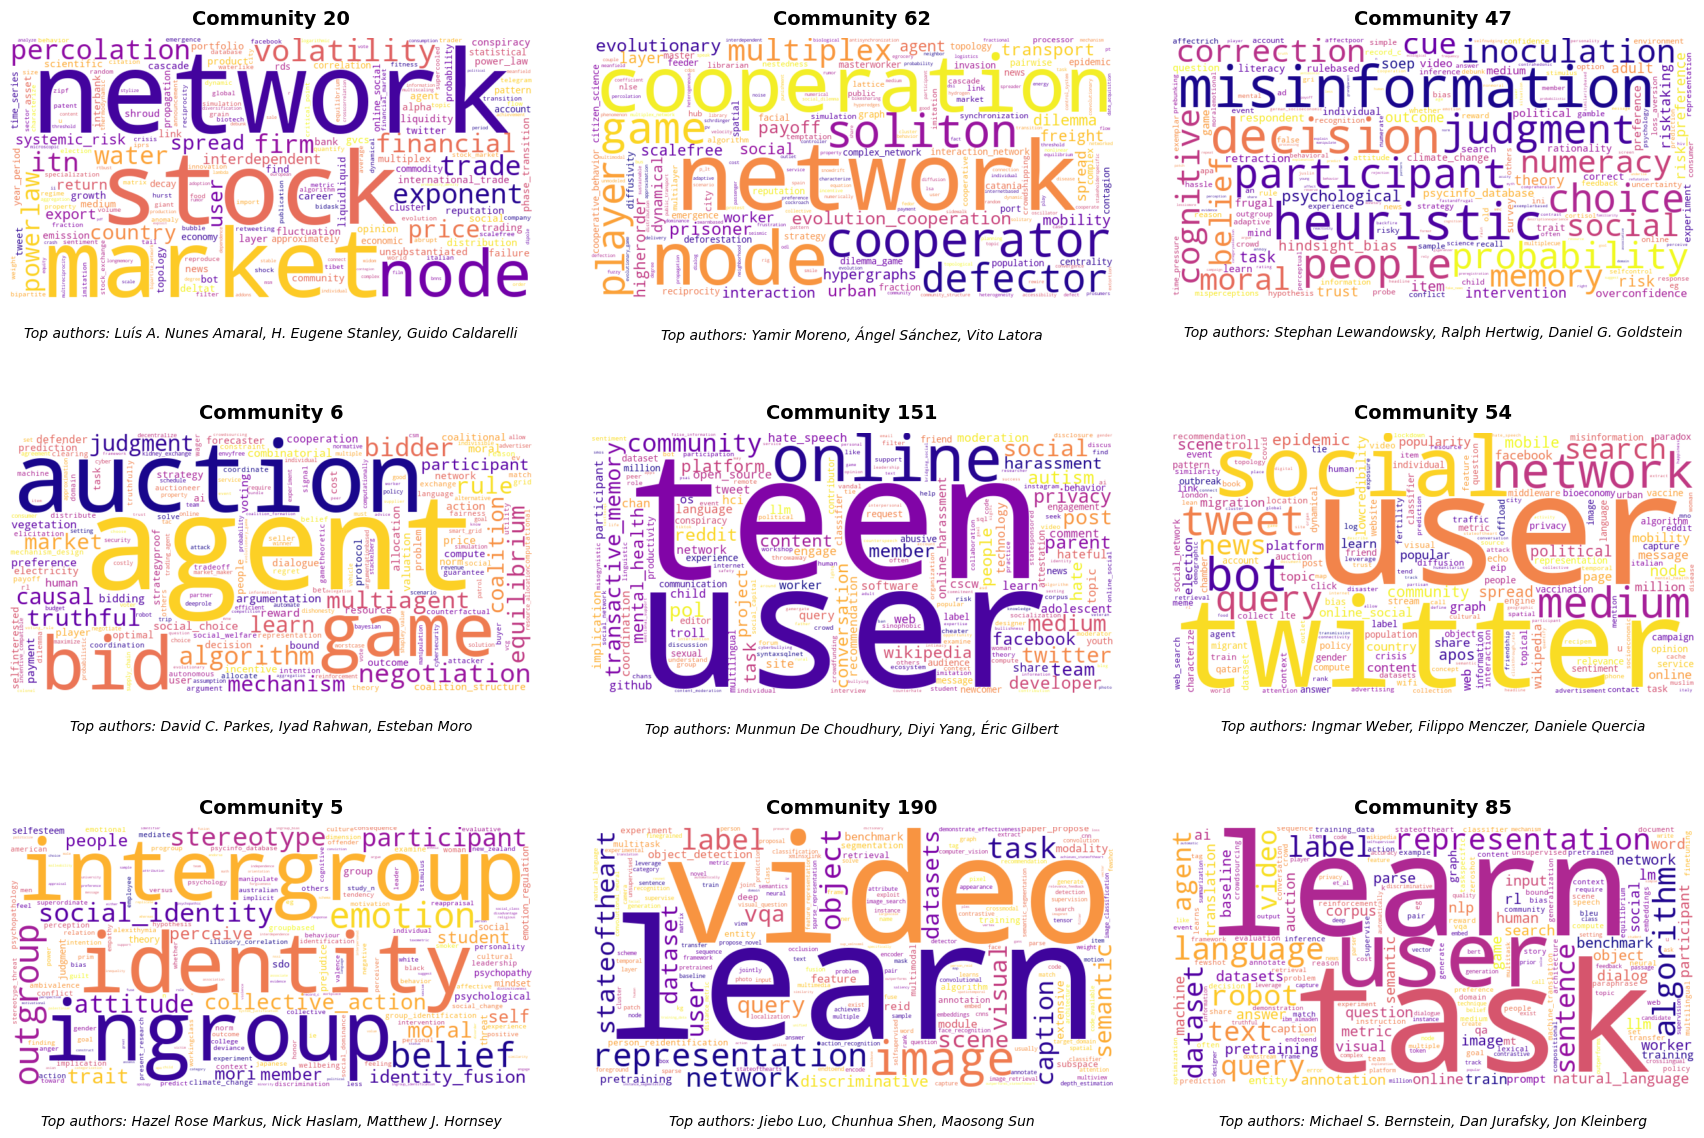

In [80]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i,id in enumerate(top_9_id_list):
    ax = axes[i]

    items = TFIDF[id].items()
    authors = top_9_id_dict[id]["authors"]

    terms_dict = {
        word: float(score)
        for word, score in items   
        if score > 0
    }

   # Create a nicer word cloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='plasma',          
        contour_width=1,
        contour_color='black',
        max_words=200
    ).generate_from_frequencies(terms_dict)
    
    # Plot
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    
    # Format authors nicely 
    authors_str = ", ".join(authors[:3])
    
    # Stylish title
    ax.set_title(
        f"Community {id}",
        fontsize=14,
        fontweight='bold',
        pad=10
    )
    
    # Subtitle (authors)
    ax.text(
        0.5, -0.1,
        f"Top authors: {authors_str}",
        ha='center',
        va='top',
        transform=ax.transAxes,
        fontsize=10,
        style='italic'
    )

# Remove empty subplots if <9 communities
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

- ##### __Comment on your results. What can you conclude on the different sub-communities in Computational Social Science?__

- ##### __Look up online the top author in each community. In light of your search, do your results make sense?__

### __Exercise 3: Computational Social Science__
- ##### __In light of your data-driven analysis, has your understanding of the field changed? How?__